In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fisheye
import uproot as up
import pandas as pd
import awkward as ak

import matplotlib.cm as cm

import importlib
importlib.reload(fisheye)

<module 'fisheye' from 'c:\\Users\\bglen\\Research\\XLZD\\Fisheye\\fisheye.py'>

In [2]:
camera = fisheye.Fisheye()

camera.PrintInfo()
camera.DefineSensor(pixel_size_mm=0.1, num_pixels_x=100, num_pixels_y=100)
camera.CalculateFocalLength()



Distance to object: 7.00 cm
Field of view radius: 30.00 cm
Field of view angle: 76.87 degrees
Projection type: stereographic
Array size: 10.00 mm x 10.00 mm
Max image radius: 5.00 mm
Pixel size: 0.10 mm
Number of pixels: 100 x 100


30.0


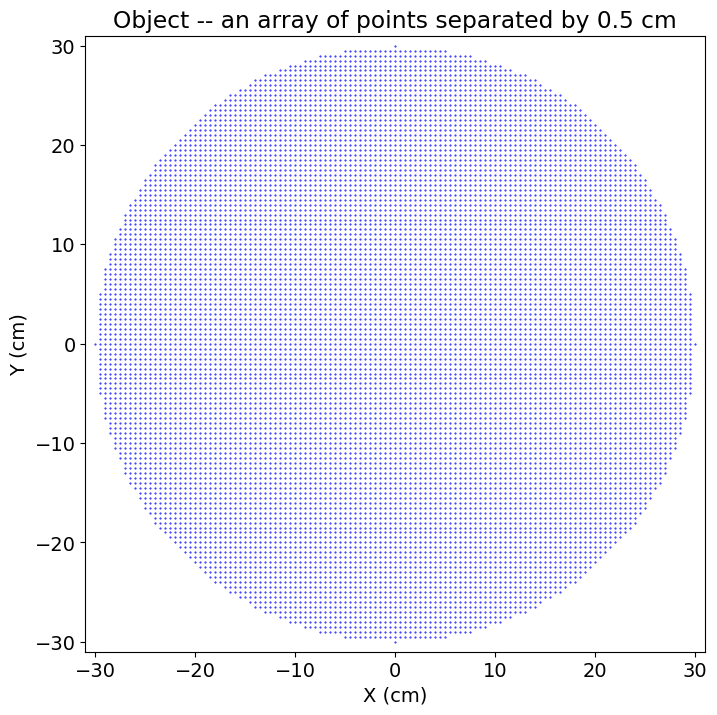

In [3]:
# Define my object as a grid of points in 2D space (the object plane), each weighted by one.
point_spacing_cm = 0.5 # cm
print(camera.field_of_view_radius_cm)
object_plane_x = np.arange(-camera.field_of_view_radius_cm, camera.field_of_view_radius_cm + point_spacing_cm, point_spacing_cm)
object_plane_y = np.arange(-camera.field_of_view_radius_cm, camera.field_of_view_radius_cm + point_spacing_cm, point_spacing_cm)

object_plane_X, object_plane_Y = np.meshgrid(object_plane_x, object_plane_y)
mask = np.sqrt(object_plane_X**2 + object_plane_Y**2) <= camera.field_of_view_radius_cm
object_plane_X = object_plane_X[mask]
object_plane_Y = object_plane_Y[mask]

plt.figure(figsize=(8, 8))
plt.rcParams['font.size'] = 14
plt.scatter(object_plane_X, object_plane_Y, s=0.2, color='blue')
plt.title('Object -- an array of points separated by {:.1f} cm'.format(point_spacing_cm))
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.xlim(-camera.field_of_view_radius_cm - 1, camera.field_of_view_radius_cm + 1)
plt.ylim(-camera.field_of_view_radius_cm - 1, camera.field_of_view_radius_cm + 1)
# plt.grid()

# Flatten the grid to get a list of points. the Z coordinate is just the distance to the object plane, which is constant for all points.
object_points_3d = np.column_stack((object_plane_X.flatten(), object_plane_Y.flatten(), np.ones(object_plane_X.size) * camera.distance_to_object_cm))
object_weights_3d = np.ones(object_points_3d.shape[0]) # All points have equal weight for now.

(-6.0, 6.0)

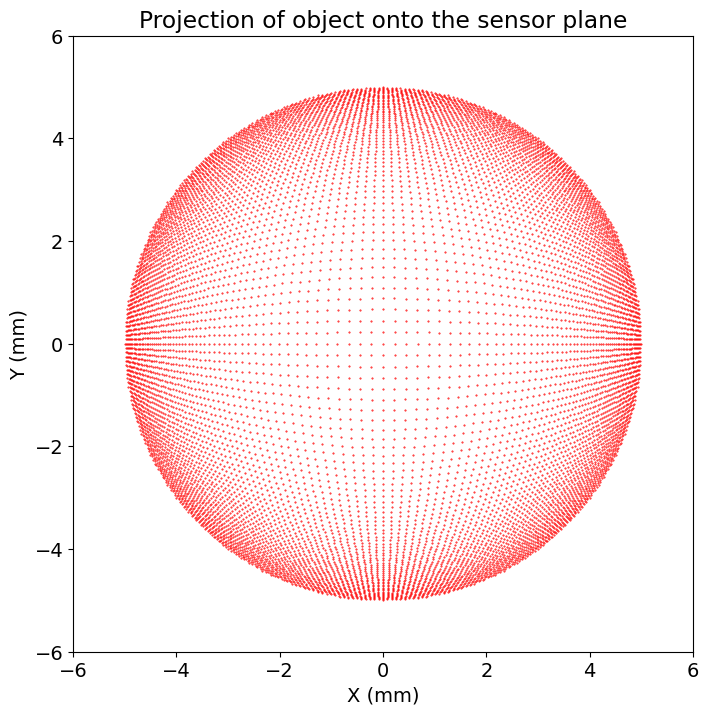

In [4]:
camera.DefineObject(object_points_3d, object_weights_3d)
camera.ProjectPoints()

# Plot the image points
plt.figure(figsize=(8, 8))
plt.rcParams['font.size'] = 14
plt.scatter(camera.image_points_2d_mm[:, 0], camera.image_points_2d_mm[:, 1], s=0.2, color='red')
plt.title('Projection of object onto the sensor plane')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.xlim(-camera.sensor.max_image_radius_mm - 1, camera.sensor.max_image_radius_mm + 1)
plt.ylim(-camera.sensor.max_image_radius_mm - 1, camera.sensor.max_image_radius_mm + 1)

Text(0, 0.5, 'Pixel Y')

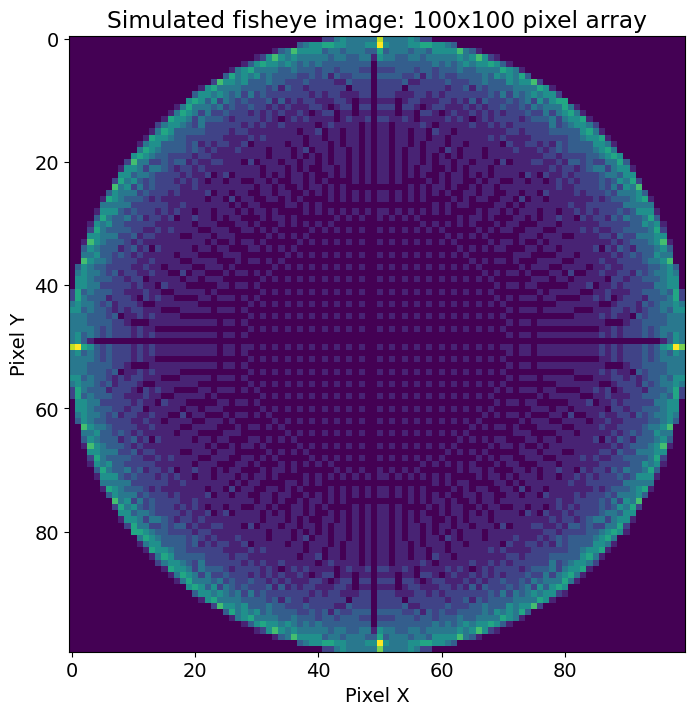

In [5]:
camera.ProduceImage()

image = camera.sensor_image
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title('Simulated fisheye image: 100x100 pixel array')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

Distance to object: 7.00 cm
Field of view radius: 30.00 cm
Field of view angle: 76.87 degrees
Projection type: stereographic
Array size: 10.24 mm x 10.24 mm
Max image radius: 5.12 mm
Pixel size: 0.01 mm
Number of pixels: 1024 x 1024


Text(0, 0.5, 'Pixel Y')

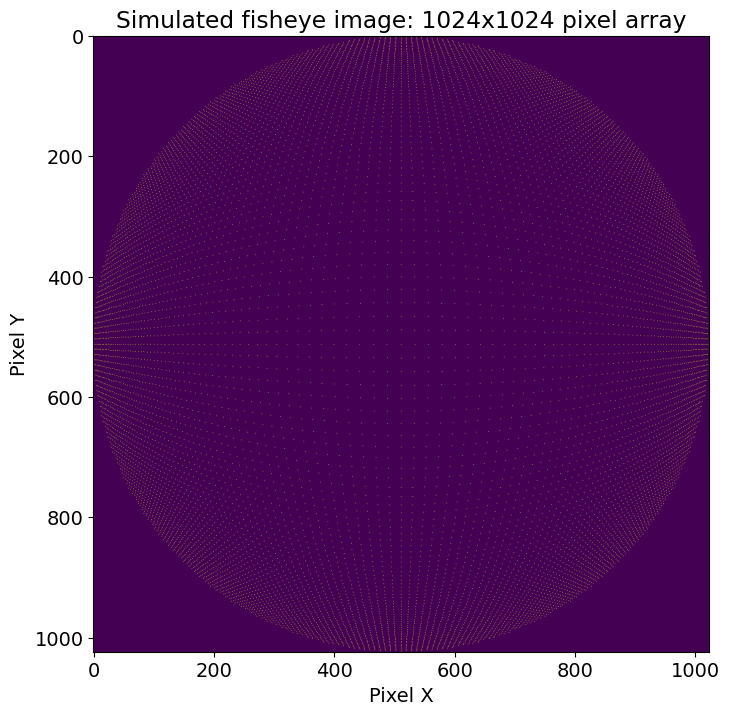

In [6]:
# Do the same thing but with a higher resolution sensor and smaller pixel size to see the difference.
# Here the pixels are 10um and the sensor is 1024x1024 pixels.

camera_MP = fisheye.Fisheye()

camera_MP.PrintInfo()

camera_MP.DefineSensor(pixel_size_mm=0.01, num_pixels_x=1024, num_pixels_y=1024)
camera_MP.CalculateFocalLength()
camera_MP.DefineObject(object_points_3d, object_weights_3d)
camera_MP.ProjectPoints()
camera_MP.ProduceImage()

image = camera_MP.sensor_image
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title('Simulated fisheye image: 1024x1024 pixel array')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

(850.0, 900.0)

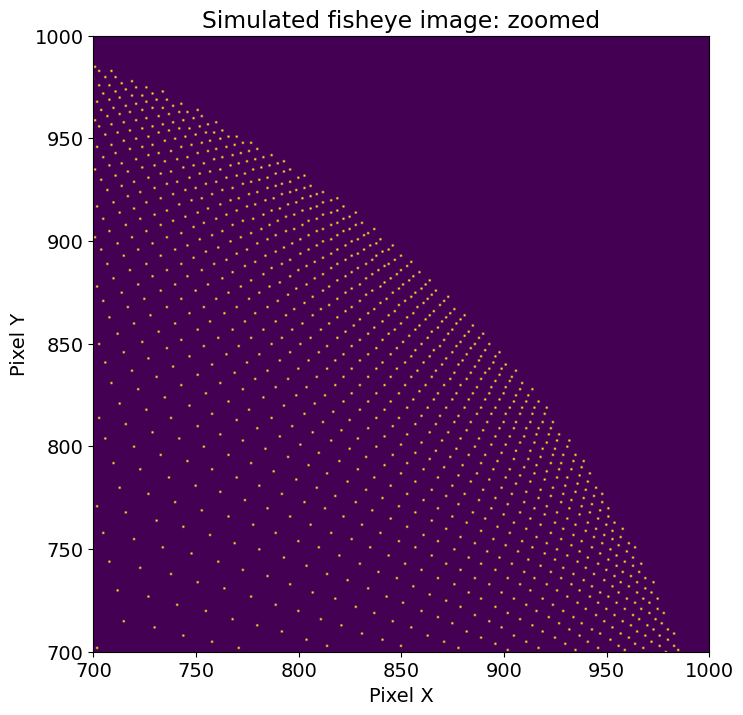

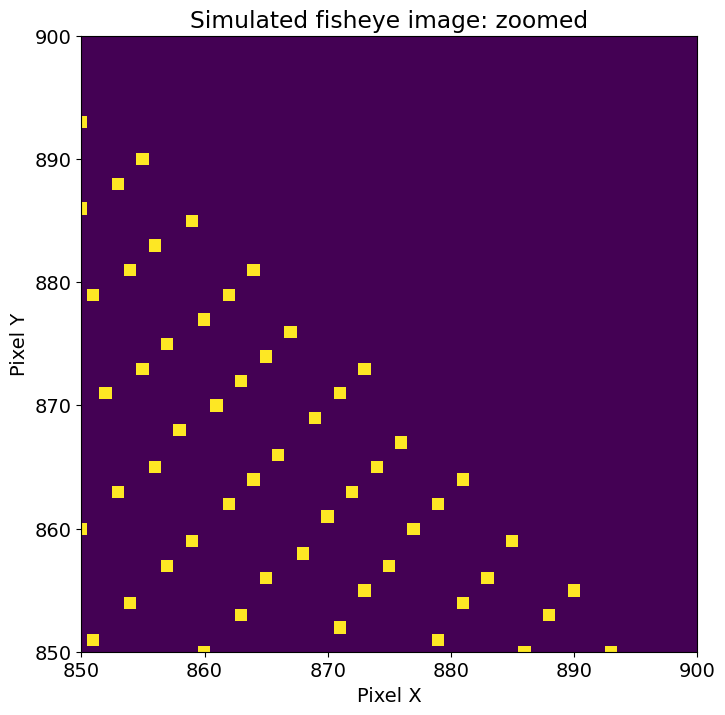

In [7]:
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title('Simulated fisheye image: zoomed')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.xlim(700,1000)
plt.ylim(700,1000)


plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title('Simulated fisheye image: zoomed')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.xlim(850,900)
plt.ylim(850,900)

Array size: 10.24 mm x 10.24 mm
Max image radius: 5.12 mm
Pixel size: 0.01 mm
Number of pixels: 1024 x 1024
{'n_input_points': 50, 'n_valid_points': 50, 'n_generated_photons': 2500, 'count_mode': 'deterministic', 'kernel_sigma_um': 1000.0, 'z_range_mm': [0.0, 0.1], 'rng_seed': 123}


(800.0, 900.0)

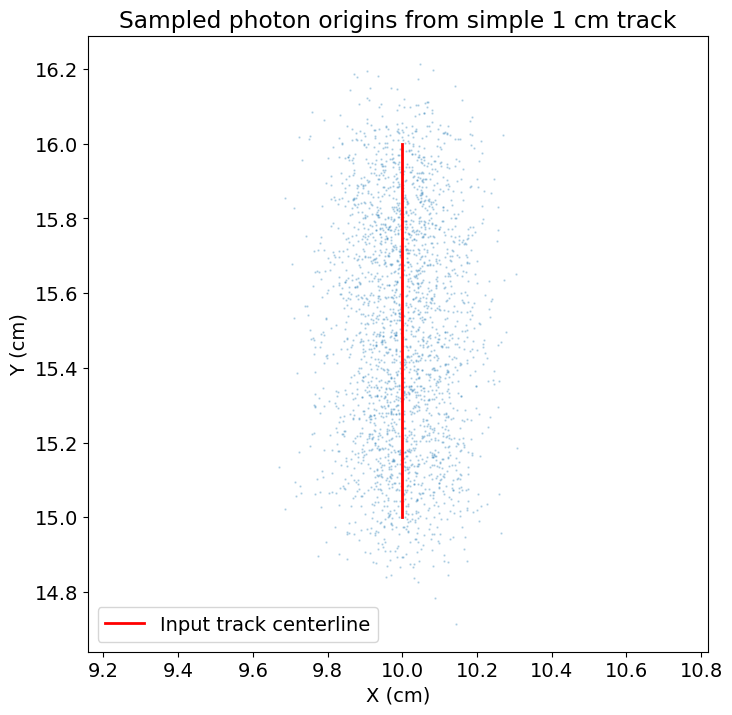

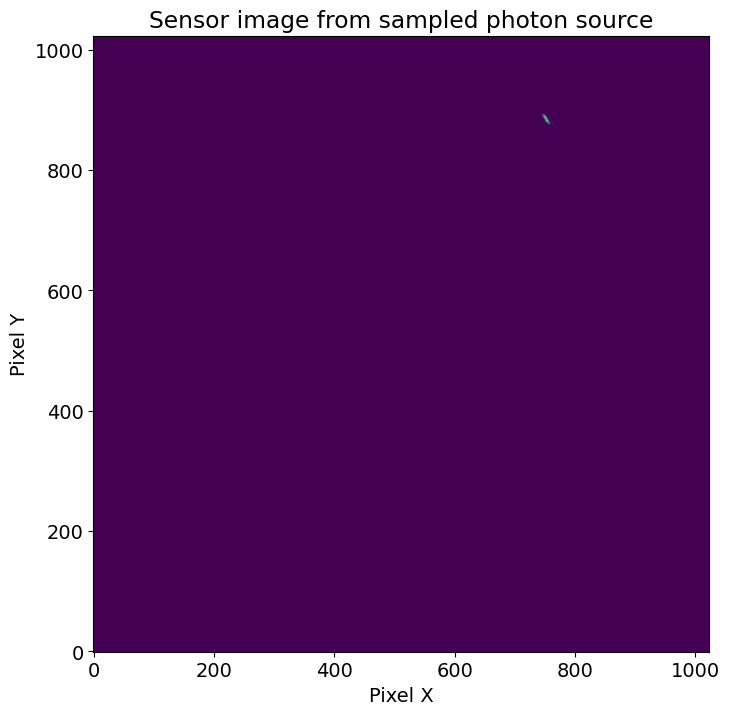

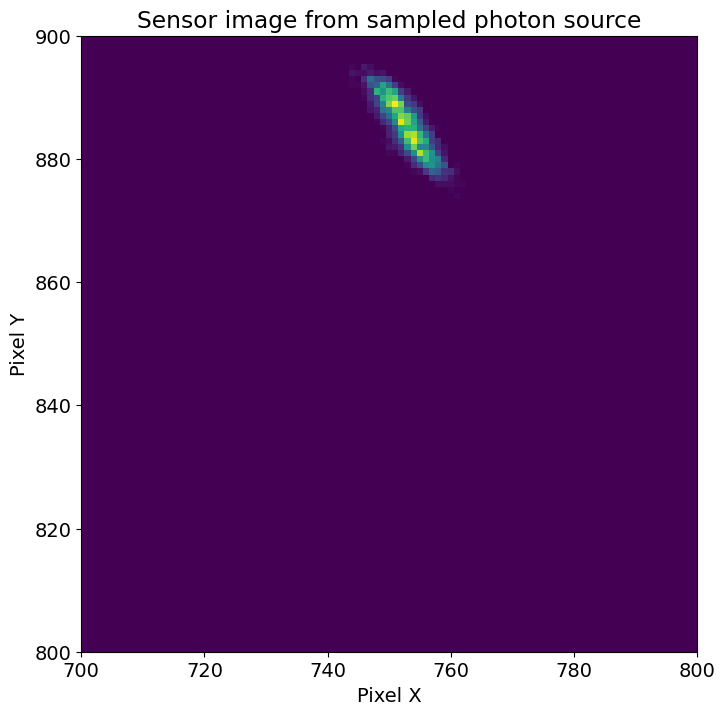

In [8]:
# Simple test: track from (x, y) = (10 cm, 15 cm) to (10 cm, 16 cm)
import importlib
importlib.reload(fisheye)

# Build a short vertical track in +y with uniform deposited energy per sample point.
n_track_points = 50
track_y_cm = np.linspace(15.0, 16.0, n_track_points)
track_x_cm = np.full(n_track_points, 10.0)
track_E = np.ones(n_track_points)
track_xyE = np.column_stack((track_x_cm, track_y_cm, track_E))

camera_track = fisheye.Fisheye(field_of_view_radius_cm=30.0)
camera_track.DefineSensor(pixel_size_mm=0.01, num_pixels_x=1024, num_pixels_y=1024)
camera_track.CalculateFocalLength()

source_out = camera_track.CreatePhotonSourceFromTrack(
    track_xyE,
    photons_per_energy=50.0,
    kernel_sigma_um=1000,
    z_min_mm=0.0,
    z_max_mm=0.1,
    count_mode='deterministic',
    rng_seed=123
 )
print(source_out['metadata'])

# Visualize photon origins in object space (x-y).
plt.figure(figsize=(8, 8))
plt.scatter(camera_track.object_points_3d[:, 0], camera_track.object_points_3d[:, 1], s=0.5, alpha=0.25)
plt.plot(track_x_cm, track_y_cm, color='red', linewidth=2, label='Input track centerline')
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title('Sampled photon origins from simple 1 cm track')
plt.legend()
plt.axis('equal')

camera_track.ProjectPoints()
camera_track.ProduceImage()

plt.figure(figsize=(8, 8))
plt.imshow(camera_track.sensor_image, origin='lower')
plt.title('Sensor image from sampled photon source')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
# plt.colorbar(label='Photon count')


plt.figure(figsize=(8, 8))
plt.imshow(camera_track.sensor_image, origin='lower')
plt.title('Sensor image from sampled photon source')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.xlim(700,800)
plt.ylim(800,900)


Array size: 10.24 mm x 10.24 mm
Max image radius: 5.12 mm
Pixel size: 0.01 mm
Number of pixels: 1024 x 1024
{'n_input_points': 500, 'n_valid_points': 500, 'n_generated_photons': 25000, 'count_mode': 'deterministic', 'kernel_sigma_um': 100.0, 'z_range_mm': [0.0, 0.1], 'rng_seed': 123}
754
878


(828.0, 928.0)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


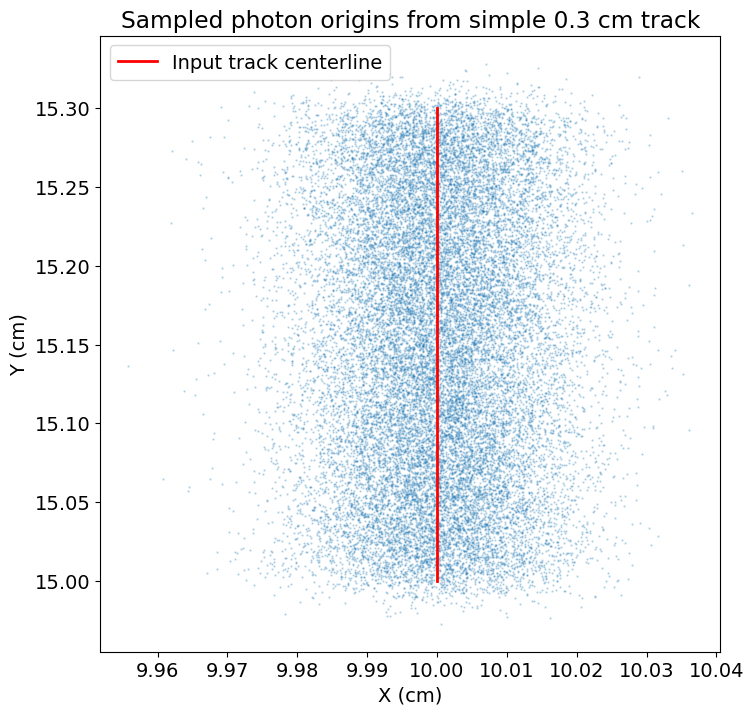

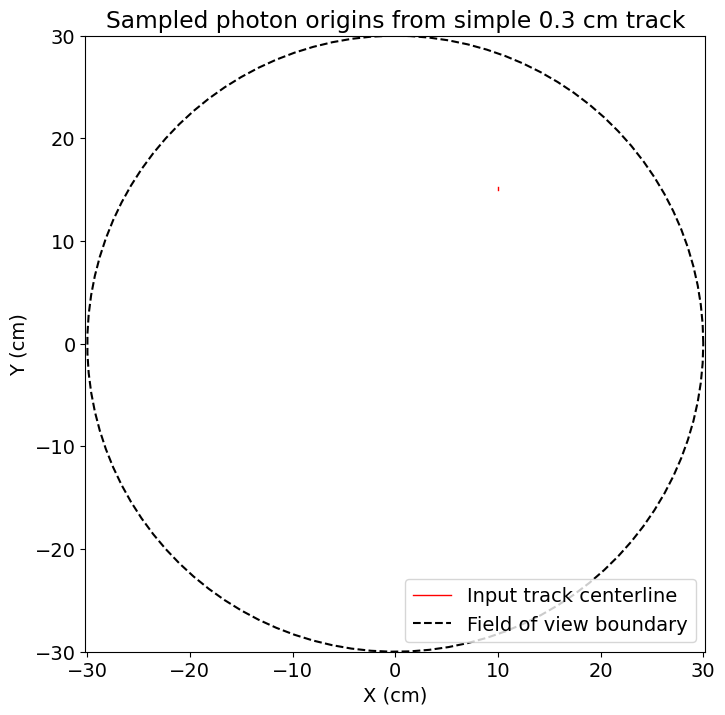

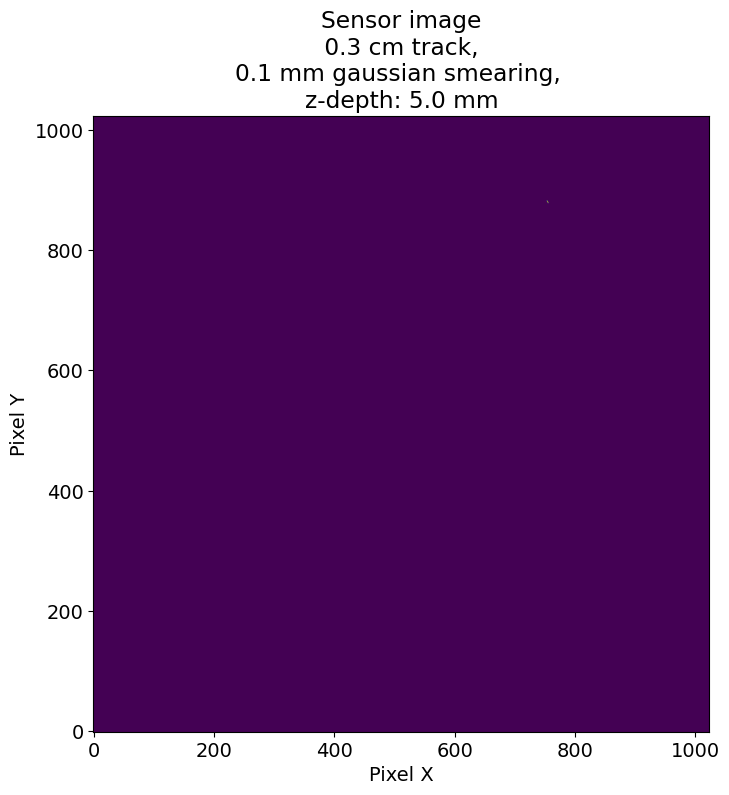

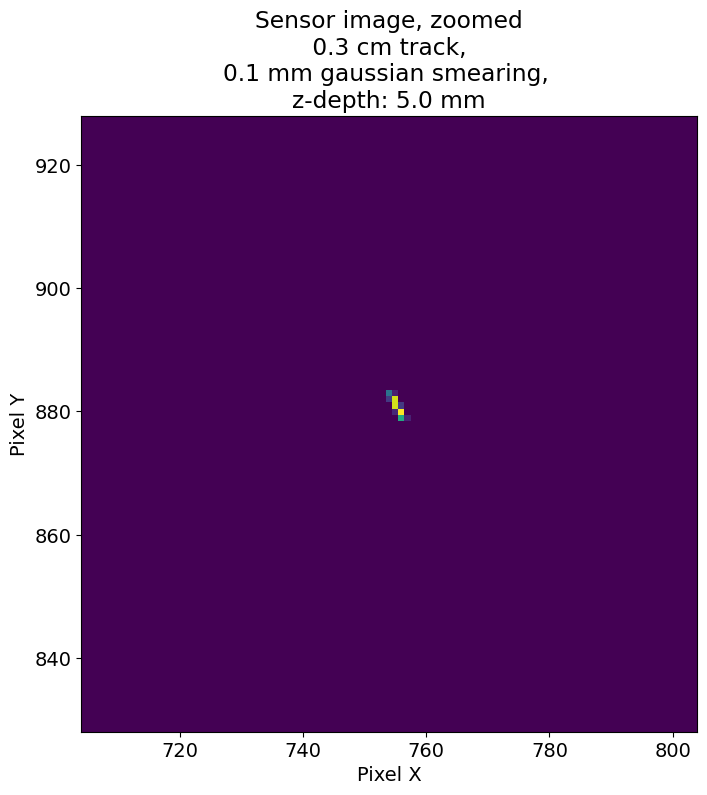

In [9]:
# Simple test: track from (x, y) = (10 cm, 15 cm) to (10 cm, 16 cm)
import importlib
importlib.reload(fisheye)

track_length_cm = 0.3
track_angle_phi_deg = 0
kernel_sigma_um = 100
z_min_mm = 0.0
z_max_mm = 5.
track_offset_x_cm = 10.0
track_offset_y_cm = 15.0

# Build a short vertical track in +y with uniform deposited energy per sample point.
n_track_points = 500
track_y_cm = np.linspace(0., 0.3, n_track_points) + track_offset_y_cm
track_x_cm = np.full(n_track_points, track_offset_x_cm)
track_E = np.ones(n_track_points)
track_xyE = np.column_stack((track_x_cm, track_y_cm, track_E))

camera_track = fisheye.Fisheye(field_of_view_radius_cm=30.0)
camera_track.DefineSensor(pixel_size_mm=0.01, num_pixels_x=1024, num_pixels_y=1024)
camera_track.CalculateFocalLength()

source_out = camera_track.CreatePhotonSourceFromTrack(
    track_xyE,
    photons_per_energy=50.0,
    kernel_sigma_um=kernel_sigma_um,
    z_min_mm=0.0,
    z_max_mm=0.1,
    count_mode='deterministic',
    rng_seed=123
 )
print(source_out['metadata'])

# Visualize photon origins in object space (x-y).
plt.figure(figsize=(8, 8))
plt.scatter(camera_track.object_points_3d[:, 0], camera_track.object_points_3d[:, 1], s=0.5, alpha=0.25)
plt.plot(track_x_cm, track_y_cm, color='red', linewidth=2, label='Input track centerline')
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title('Sampled photon origins from simple {:2.2} cm track'.format(track_y_cm[-1] - track_y_cm[0]))
plt.legend()


# Visualize photon origins in object space (x-y).
plt.figure(figsize=(8, 8))
# plt.scatter(camera_track.object_points_3d[:, 0], camera_track.object_points_3d[:, 1], s=0.5, alpha=0.25)
plt.plot(track_x_cm, track_y_cm, color='red', linewidth=1, label='Input track centerline')
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title('Sampled photon origins from simple {:2.2} cm track'.format(track_y_cm[-1] - track_y_cm[0]))
plt.axis('equal')
plt.xlim(-30,30)
plt.ylim(-30,30)
#Plot a circle with radius 30cm, with a dashed black line to show the field of view boundary.
theta = np.linspace(0, 2*np.pi, 100)
x_circle = camera_track.field_of_view_radius_cm * np.cos(theta)
y_circle = camera_track.field_of_view_radius_cm * np.sin(theta)
plt.plot(x_circle, y_circle, color='black', linestyle='--', label='Field of view boundary')
plt.legend(loc='lower right')

camera_track.ProjectPoints()
camera_track.ProduceImage()

plt.figure(figsize=(8, 8))
plt.imshow(camera_track.sensor_image, origin='lower')
plt.title('Sensor image\n {:2.2} cm track, \n{:2.1f} mm gaussian smearing, \nz-depth: {:2.1f} mm'.format(track_y_cm[-1] - track_y_cm[0], kernel_sigma_um/1000, z_max_mm-z_min_mm))
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
# plt.colorbar(label='Photon count')


plt.figure(figsize=(8, 8))
plt.imshow(camera_track.sensor_image, origin='lower')
plt.title('Sensor image, zoomed\n {:2.2} cm track, \n{:2.1f} mm gaussian smearing, \nz-depth: {:2.1f} mm'.format(track_y_cm[-1] - track_y_cm[0], kernel_sigma_um/1000, z_max_mm-z_min_mm))
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
# Need to get xlim and ylim from the image points to zoom in on the track.
# sensor_image is a 2D array of the pixel weights. I need the x and y indices of the maximum pixel
track_image_points = camera_track.image_points_2d_mm
max_x_idx = np.argmax(np.argmax(camera_track.sensor_image, axis=0))
print(max_x_idx)
max_y_idx = np.argmax(np.argmax(camera_track.sensor_image, axis=1))
print(max_y_idx)

plt.xlim(max_x_idx - 50, max_x_idx + 50)
plt.ylim(max_y_idx - 50, max_y_idx + 50)




Array size: 10.24 mm x 10.24 mm
Max image radius: 5.12 mm
Pixel size: 0.01 mm
Number of pixels: 1024 x 1024
{'n_input_points': 500, 'n_valid_points': 500, 'n_generated_photons': 25000, 'count_mode': 'deterministic', 'kernel_sigma_um': 100.0, 'z_range_mm': [0.0, 5.0], 'rng_seed': 123}


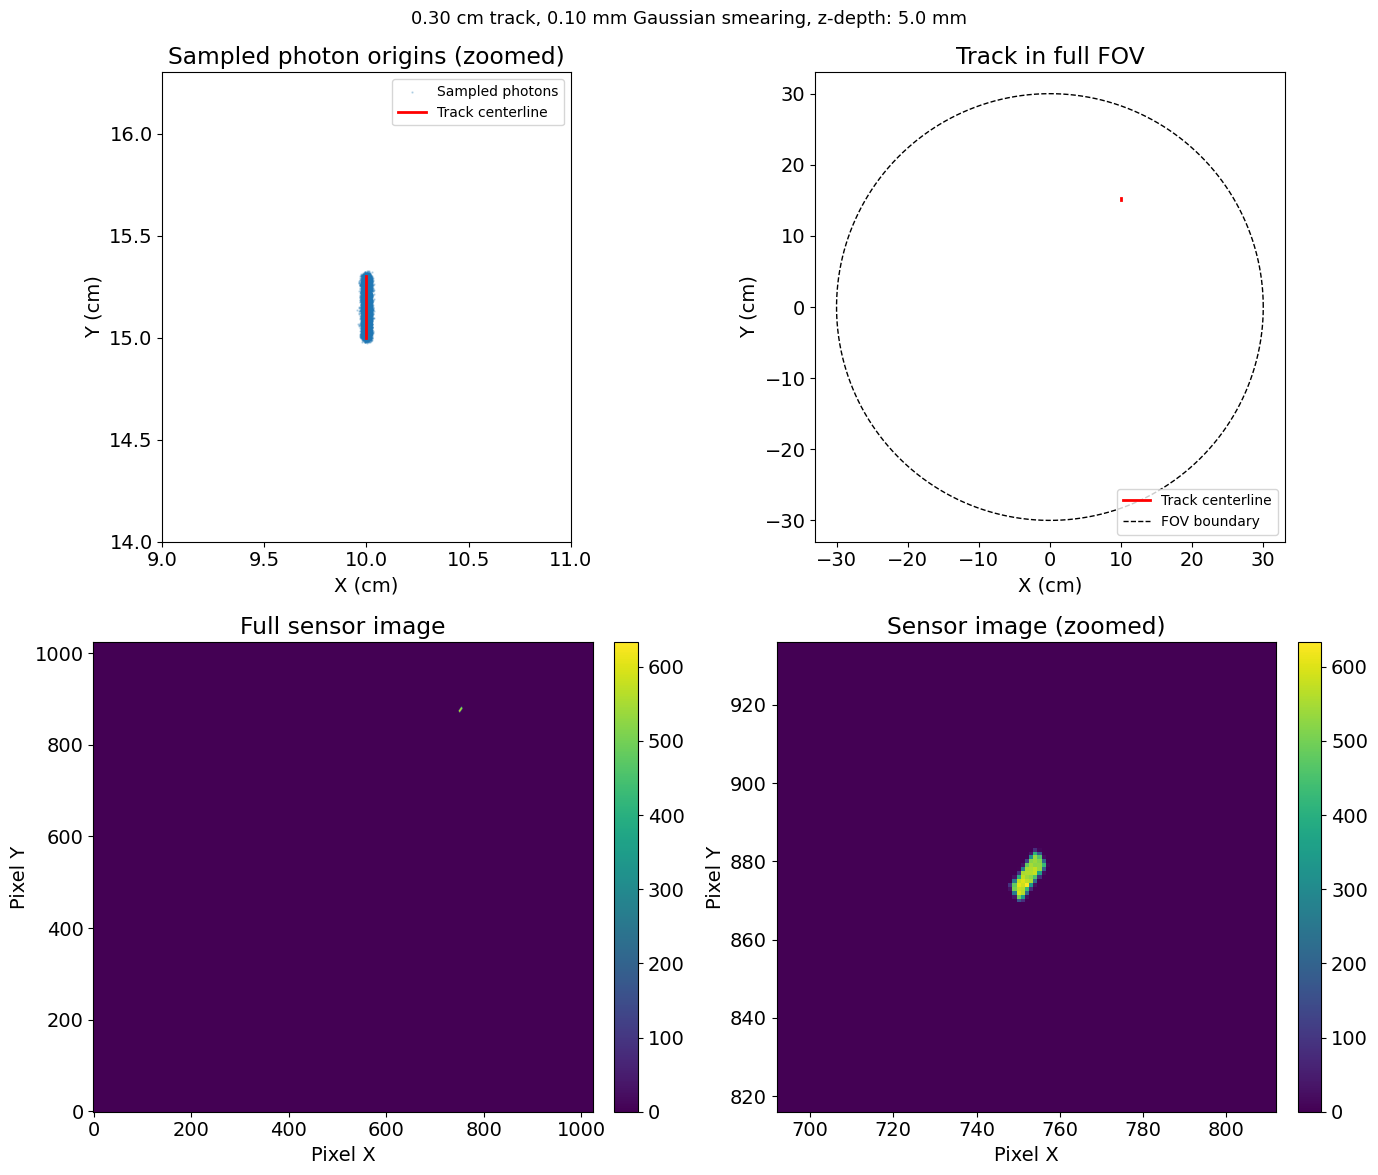

In [10]:

import importlib
importlib.reload(fisheye)

def simulate_and_plot_track(
    track_offset_x_cm=10.0,
    track_offset_y_cm=15.0,
    track_length_cm=0.3,
    n_track_points=500,
    kernel_sigma_um=100.0,
    z_min_mm=0.0,
    z_max_mm=.1,
    photons_per_energy=50.0,
    count_mode='deterministic',
    rng_seed=123,
    pixel_size_mm=0.01,
    num_pixels=1024,
    field_of_view_radius_cm=30.0,
):
    """Build a vertical track, sample photons, project, and display four subplots in one figure."""

    # --- Build track ---
    track_y_cm = np.linspace(track_offset_y_cm, track_offset_y_cm + track_length_cm, n_track_points)
    track_x_cm = np.full(n_track_points, track_offset_x_cm)
    track_xyE = np.column_stack((track_x_cm, track_y_cm, np.ones(n_track_points)))

    # --- Camera setup ---
    cam = fisheye.Fisheye(field_of_view_radius_cm=field_of_view_radius_cm)
    cam.DefineSensor(pixel_size_mm=pixel_size_mm, num_pixels_x=num_pixels, num_pixels_y=num_pixels)
    cam.CalculateFocalLength()

    # --- Sample photons ---
    source_out = cam.CreatePhotonSourceFromTrack(
        track_xyE,
        photons_per_energy=photons_per_energy,
        kernel_sigma_um=kernel_sigma_um,
        z_min_mm=z_min_mm,
        z_max_mm=z_max_mm,
        count_mode=count_mode,
        rng_seed=rng_seed,
    )
    print(source_out['metadata'])

    # --- Project and render ---
    cam.ProjectPoints()
    cam.ProduceImage()

    # --- Find zoom center on sensor image ---
    col_sums = np.sum(cam.sensor_image, axis=0)
    row_sums = np.sum(cam.sensor_image, axis=1)
    cx = int(np.average(np.arange(len(col_sums)), weights=col_sums + 1e-30))
    cy = int(np.average(np.arange(len(row_sums)), weights=row_sums + 1e-30))
    zoom_half = 60

    title_suffix = (
        f'{track_length_cm:.2f} cm track, '
        f'{kernel_sigma_um/1000:.2f} mm Gaussian smearing, '
        f'z-depth: {z_max_mm - z_min_mm:.1f} mm'
    )

    # --- FOV circle ---
    theta = np.linspace(0, 2 * np.pi, 200)
    fov_x = field_of_view_radius_cm * np.cos(theta)
    fov_y = field_of_view_radius_cm * np.sin(theta)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(title_suffix, fontsize=13)

    # Panel 1: photon origins scatter, zoomed in on track
    ax = axes[0, 0]
    ax.scatter(cam.object_points_3d[:, 0], cam.object_points_3d[:, 1],
               s=0.5, alpha=0.25, label='Sampled photons')
    ax.plot(track_x_cm, track_y_cm, color='red', linewidth=2, label='Track centerline')
    pad = max(1.0, kernel_sigma_um * 1e-4 * 5)
    ax.set_xlim(track_offset_x_cm - pad, track_offset_x_cm + pad)
    ax.set_ylim(track_offset_y_cm - pad, track_offset_y_cm + track_length_cm + pad)
    ax.set_xlabel('X (cm)')
    ax.set_ylabel('Y (cm)')
    ax.set_title('Sampled photon origins (zoomed)')
    ax.legend(fontsize=10)
    ax.set_aspect('equal')

    # Panel 2: full FOV view with track and FOV boundary
    ax = axes[0, 1]
    ax.plot(track_x_cm, track_y_cm, color='red', linewidth=2, label='Track centerline')
    ax.plot(fov_x, fov_y, color='black', linestyle='--', linewidth=1, label='FOV boundary')
    ax.set_xlim(-field_of_view_radius_cm * 1.1, field_of_view_radius_cm * 1.1)
    ax.set_ylim(-field_of_view_radius_cm * 1.1, field_of_view_radius_cm * 1.1)
    ax.set_xlabel('X (cm)')
    ax.set_ylabel('Y (cm)')
    ax.set_title('Track in full FOV')
    ax.legend(fontsize=10, loc='lower right')
    ax.set_aspect('equal')

    # Panel 3: full sensor image
    ax = axes[1, 0]
    im = ax.imshow(cam.sensor_image, origin='lower', aspect='auto')
    ax.set_title('Full sensor image')
    ax.set_xlabel('Pixel X')
    ax.set_ylabel('Pixel Y')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Panel 4: zoomed sensor image
    ax = axes[1, 1]
    im = ax.imshow(cam.sensor_image, origin='lower', aspect='auto')
    ax.set_xlim(cx - zoom_half, cx + zoom_half)
    ax.set_ylim(cy - zoom_half, cy + zoom_half)
    ax.set_title('Sensor image (zoomed)')
    ax.set_xlabel('Pixel X')
    ax.set_ylabel('Pixel Y')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
    return cam, source_out


# --- Demo call ---
cam, out = simulate_and_plot_track(
    track_offset_x_cm=10.0,
    track_offset_y_cm=15.0,
    track_length_cm=0.3,
    kernel_sigma_um=100.0,
    z_min_mm=0.0,
    z_max_mm=5.0,
)


Array size: 10.24 mm x 10.24 mm
Max image radius: 5.12 mm
Pixel size: 0.01 mm
Number of pixels: 1024 x 1024
{'n_input_points': 500, 'n_valid_points': 500, 'n_generated_photons': 25000, 'count_mode': 'deterministic', 'kernel_sigma_um': 2000.0, 'z_range_mm': [0.0, 5.0], 'rng_seed': 123}


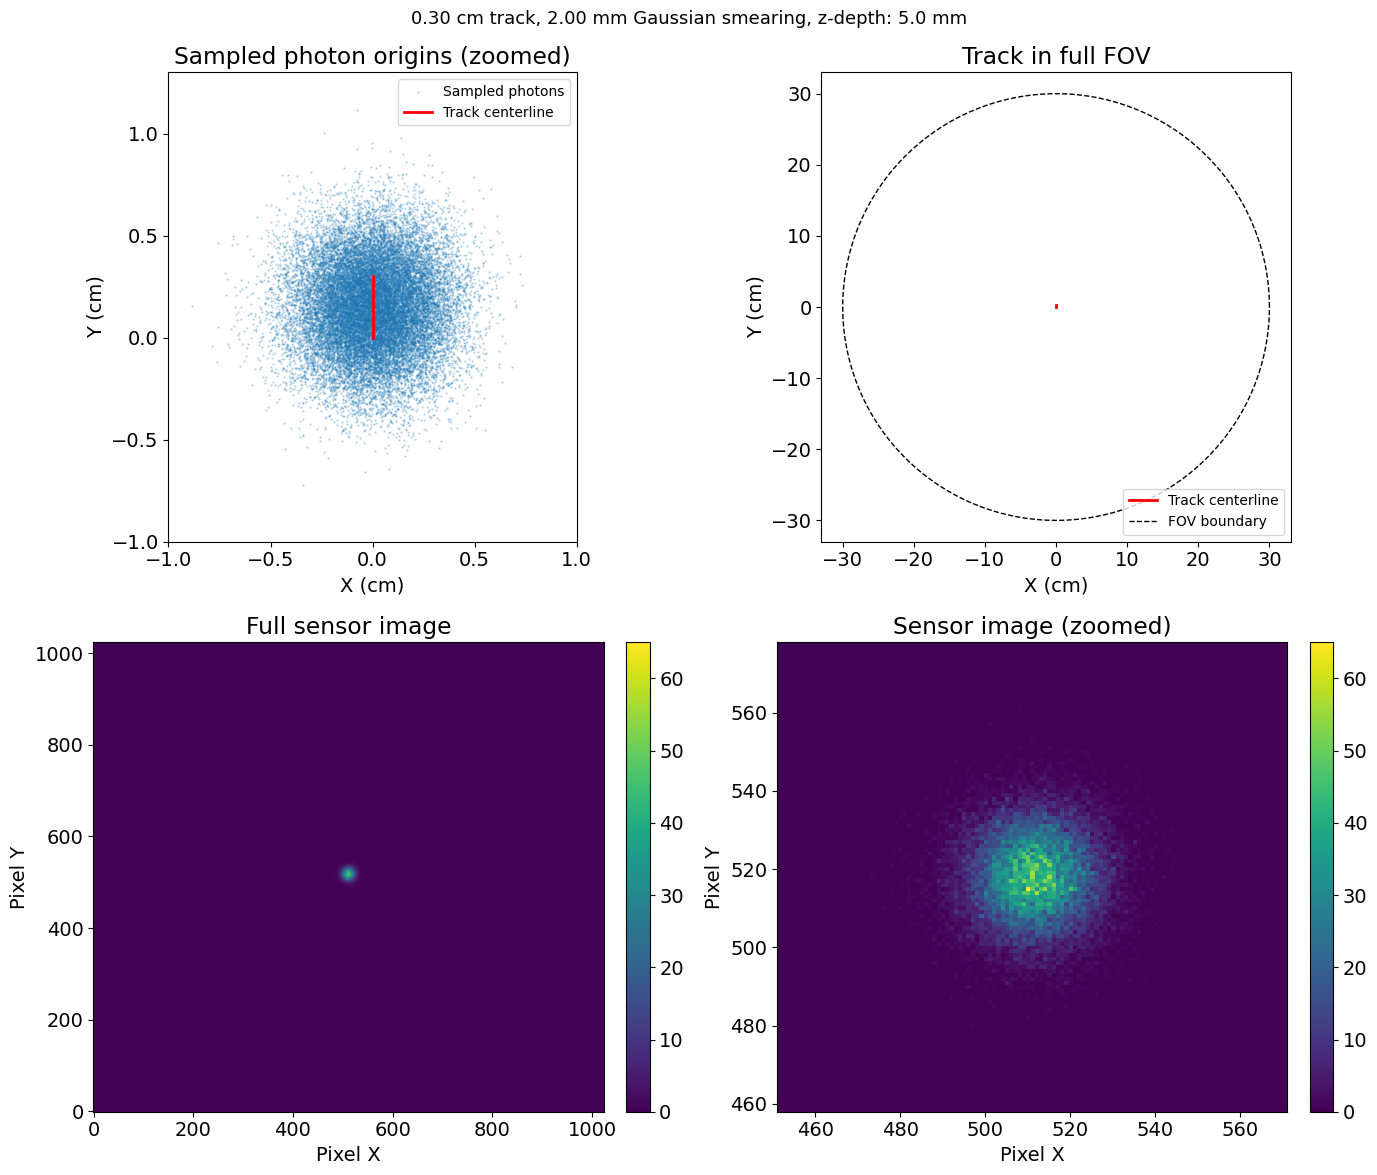

In [11]:
cam, out = simulate_and_plot_track(
    track_offset_x_cm=0.0,
    track_offset_y_cm=0.0,
    track_length_cm=0.3,
    kernel_sigma_um=2000.0,
    z_min_mm=0.0,
    z_max_mm=5.,
)

# Test Adam's function

In [55]:
importlib.reload(fisheye)


<module 'fisheye' from 'c:\\Users\\bglen\\Research\\XLZD\\Fisheye\\fisheye.py'>

# Testing straight line tracks with Adam's camera design


Distance to object: 11.15 cm
Field of view radius: 10.00 cm
Field of view angle: 41.89 degrees
Projection type: adam_01
Array size: 7.58 mm x 7.58 mm
Max image radius: 3.79 mm
Pixel size: 0.01 mm
Number of pixels: 1024 x 1024
{'n_input_points': 500, 'n_valid_points': 500, 'n_generated_photons': 2500, 'count_mode': 'deterministic', 'kernel_sigma_um': 10.0, 'z_range_mm': [0.0, 0.1], 'rng_seed': 123}


(-0.25, 0.25)

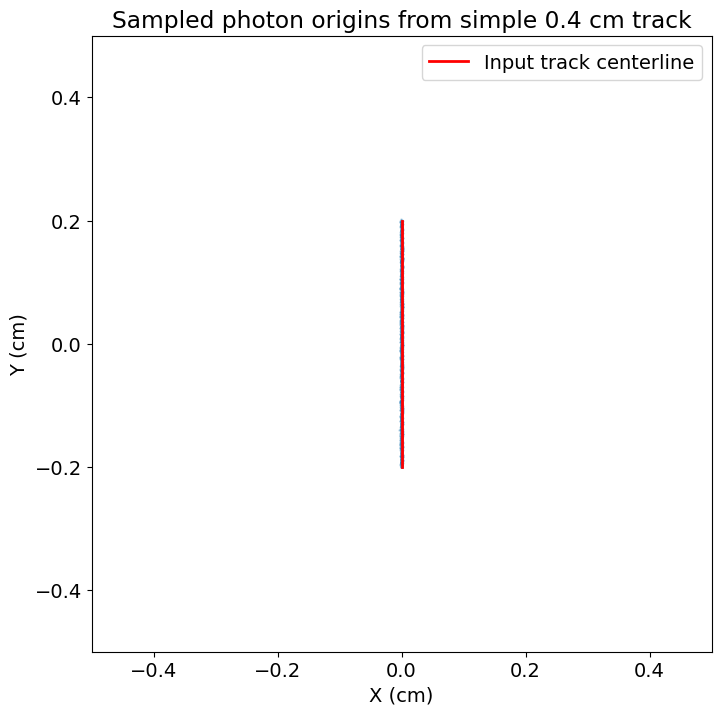

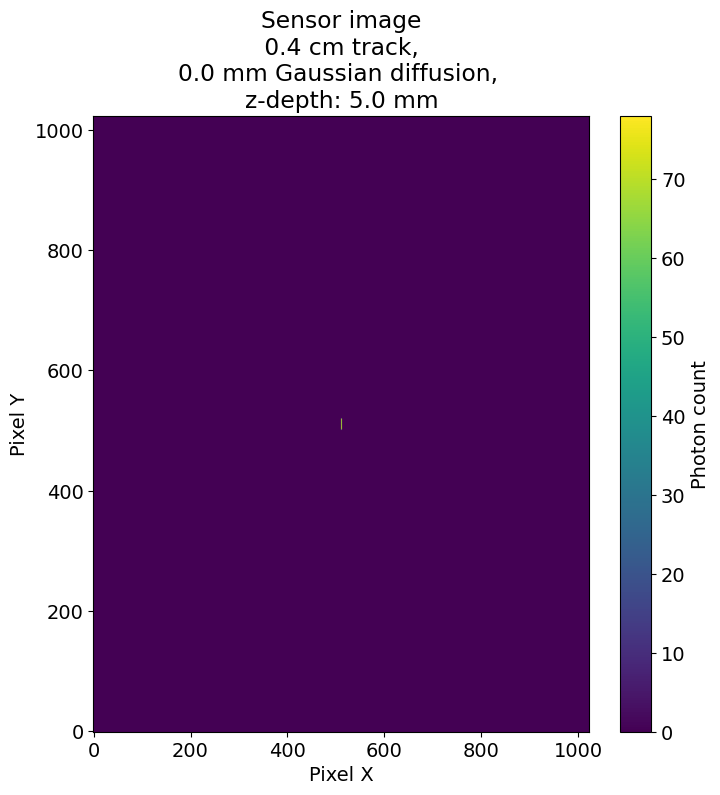

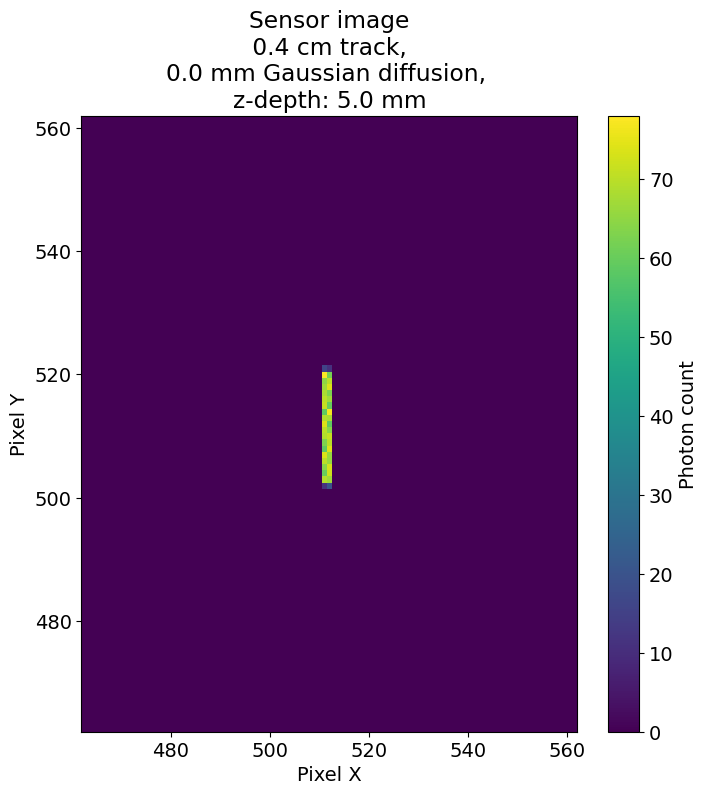

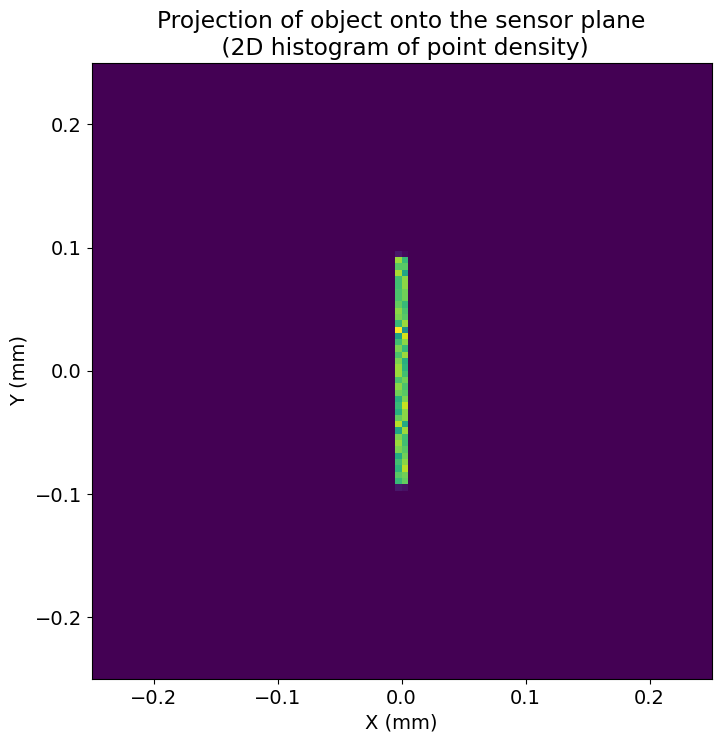

In [76]:
plt.rcParams['font.size'] = 14

track_length_cm = 0.4
track_angle_phi_deg = 0
kernel_sigma_um = 10
z_min_mm = 0.0
z_max_mm = 5.
track_offset_x_cm = 0.0
track_offset_y_cm = 0.0

# Build a short vertical track in +y with uniform deposited energy per sample point.
n_photons = 2500
n_track_points = 500
photons_per_energy = n_photons / n_track_points

track_y_cm = np.linspace(-track_length_cm/2, track_length_cm/2, n_track_points) + track_offset_y_cm
track_x_cm = np.full(n_track_points, track_offset_x_cm)
track_E = np.ones(n_track_points)
track_xyE = np.column_stack((track_x_cm, track_y_cm, track_E))

camera = fisheye.Fisheye(distance_to_object_cm=11.15, field_of_view_radius_cm=10., projection_type='adam_01')
camera.PrintInfo()
camera.DefineSensor(pixel_size_mm=0.0074, num_pixels_x=1024, num_pixels_y=1024)
camera_track.CalculateFocalLength()

source_out = camera_track.CreatePhotonSourceFromTrack(
    track_xyE,
    photons_per_energy=photons_per_energy,
    kernel_sigma_um=kernel_sigma_um,
    z_min_mm=0.0,
    z_max_mm=0.1,
    count_mode='deterministic',
    rng_seed=123
 )
print(source_out['metadata'])

# Visualize photon origins in object space (x-y).
plt.figure(figsize=(8, 8))
plt.scatter(camera_track.object_points_3d[:, 0], camera_track.object_points_3d[:, 1], s=0.5, alpha=0.25)
plt.plot(track_x_cm, track_y_cm, color='red', linewidth=2, label='Input track centerline')
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.xlim(-.5,.5)
plt.ylim(-.5,.5)
plt.title('Sampled photon origins from simple {:2.2} cm track'.format(track_y_cm[-1] - track_y_cm[0]))
plt.legend()


# --- Project and render ---
camera_track.ProjectPoints(aberration=True)
camera_track.ProduceImage()

plt.figure(figsize=(8, 8))
plt.imshow(camera_track.sensor_image, origin='lower', aspect='auto')
plt.title('Sensor image\n {:2.2} cm track, \n{:2.1f} mm Gaussian diffusion, \nz-depth: {:2.1f} mm'.format(track_y_cm[-1] - track_y_cm[0], kernel_sigma_um/1000, z_max_mm-z_min_mm))
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.colorbar(label='Photon count')



plt.figure(figsize=(8, 8))
plt.imshow(camera_track.sensor_image, origin='lower', aspect='auto')
plt.title('Sensor image\n {:2.2} cm track, \n{:2.1f} mm Gaussian diffusion, \nz-depth: {:2.1f} mm'.format(track_y_cm[-1] - track_y_cm[0], kernel_sigma_um/1000, z_max_mm-z_min_mm))
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.xlim(462,562)
plt.ylim(462,562)
plt.colorbar(label='Photon count')

plt.figure(figsize=(8, 8))
plt.hist2d(camera_track.image_points_2d_mm[:, 0], camera_track.image_points_2d_mm[:, 1], bins=2000, range=[[-camera_track.sensor.max_image_radius_mm, camera_track.sensor.max_image_radius_mm], [-camera_track.sensor.max_image_radius_mm, camera_track.sensor.max_image_radius_mm]], cmap='viridis')
plt.title('Projection of object onto the sensor plane\n (2D histogram of point density)')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.xlim(-.25,.25)
plt.ylim(-.25,.25)

# Load in G4 tracks

In [19]:
datadir = '../data/'

electrons_data_filename = 'KTonXe_liquidXe_TwoElectrons_Qbb_over_2__1e5evts_SHORTCUTS_968114238_REDUCED.root'

print('Opening file...')
electrons_file = up.open(datadir + electrons_data_filename)
electrons_tree = electrons_file['data']
print(electrons_tree.keys())
# print(electrons_tree['Event/tracks/tracks.steps'].interpretation)

print('Converting to np arrays...')
electrons_data = electrons_tree.arrays(library='np', entry_stop=-1)
print('Done.\n')

Opening file...
['stepX', 'stepY', 'stepZ', 'stepEnergy_keV', 'stepTime_ns']
Converting to np arrays...
Done.



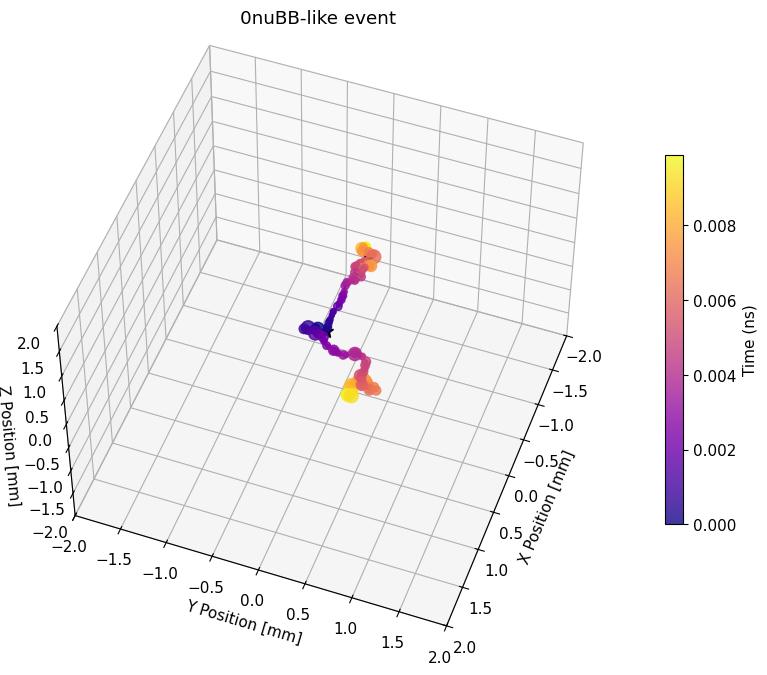

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['font.size'] = 11

idx = 2

x = electrons_data['stepX'][idx]
y = electrons_data['stepY'][idx]
z = electrons_data['stepZ'][idx]
energy = electrons_data['stepEnergy_keV'][idx]
time = electrons_data['stepTime_ns'][idx]
srt = np.argsort(time)

# print('Range of event {}: {:4.4}mm'.format(idx, ComputeRange(x[srt],y[srt],z[srt])))

marker_sizes = (energy - min(energy)) / (max(energy) - min(energy)) * 100
time_normalized = time - min(time) #(time - min(time)) / (max(time) - min(time)) * 200

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x[srt], y[srt], z[srt], s=marker_sizes[srt], c=time_normalized[srt], cmap='plasma', alpha=0.8)
p = ax.plot(np.append([0.],x[srt]), np.append([0.],y[srt]), np.append([0.],z[srt]), '-k', linewidth=1)


# idx = idx+1

x = electrons_data['stepX'][idx+1]
y = electrons_data['stepY'][idx+1]
z = electrons_data['stepZ'][idx+1]
energy = electrons_data['stepEnergy_keV'][idx+1]
time = electrons_data['stepTime_ns'][idx+1]
srt = np.argsort(time)

marker_sizes = (energy - min(energy)) / (max(energy) - min(energy)) * 100
time_normalized = time - min(time) #(time - min(time)) / (max(time) - min(time)) * 200

# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x[srt], y[srt], z[srt], s=marker_sizes[srt], c=time_normalized[srt], cmap='plasma', alpha=0.8)
p = ax.plot(np.append([0.],x[srt]), np.append([0.],y[srt]), np.append([0.],z[srt]), '-k', linewidth=1)
p2 = ax.plot(0.,0.,0.,'*',color='k',markersize=10)

box_size = 2.

ax.set_xlim(-box_size,box_size)
ax.set_ylim(-box_size,box_size)
ax.set_zlim(-box_size,box_size)
ax.view_init(elev=90, azim=0)
ax.view_init(elev=50, azim=20)

ax.set_xlabel("X Position [mm]")
ax.set_ylabel("Y Position [mm]")
ax.set_zlabel("Z Position [mm]")
ax.set_title("0nuBB-like event")

cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label("Time (ns)")

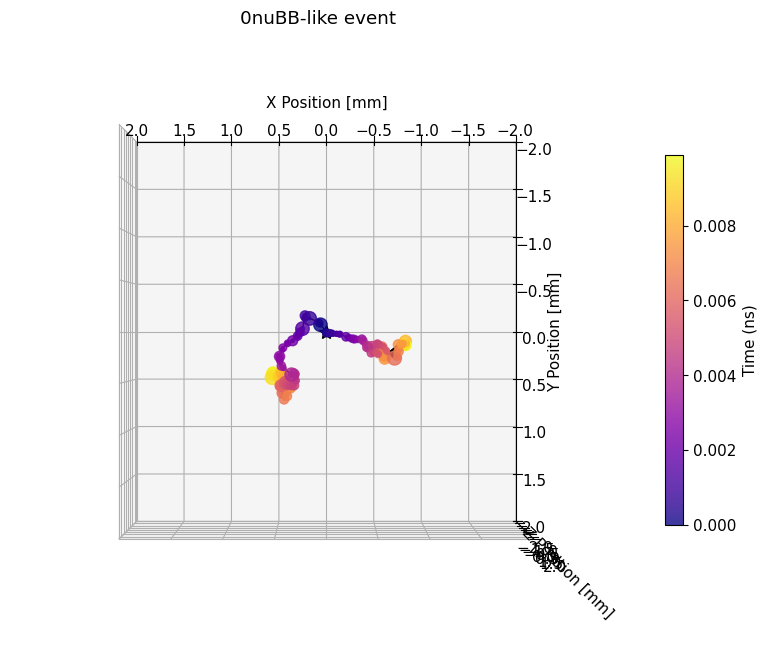

In [24]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['font.size'] = 11

idx = 2

x = electrons_data['stepX'][idx]
y = electrons_data['stepY'][idx]
z = electrons_data['stepZ'][idx]
energy = electrons_data['stepEnergy_keV'][idx]
time = electrons_data['stepTime_ns'][idx]
srt = np.argsort(time)

# print('Range of event {}: {:4.4}mm'.format(idx, ComputeRange(x[srt],y[srt],z[srt])))

marker_sizes = (energy - min(energy)) / (max(energy) - min(energy)) * 100
time_normalized = time - min(time) #(time - min(time)) / (max(time) - min(time)) * 200

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x[srt], y[srt], z[srt], s=marker_sizes[srt], c=time_normalized[srt], cmap='plasma', alpha=0.8)
p = ax.plot(np.append([0.],x[srt]), np.append([0.],y[srt]), np.append([0.],z[srt]), '-k', linewidth=1)


# idx = idx+1

x = electrons_data['stepX'][idx+1]
y = electrons_data['stepY'][idx+1]
z = electrons_data['stepZ'][idx+1]
energy = electrons_data['stepEnergy_keV'][idx+1]
time = electrons_data['stepTime_ns'][idx+1]
srt = np.argsort(time)

marker_sizes = (energy - min(energy)) / (max(energy) - min(energy)) * 100
time_normalized = time - min(time) #(time - min(time)) / (max(time) - min(time)) * 200

# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x[srt], y[srt], z[srt], s=marker_sizes[srt], c=time_normalized[srt], cmap='plasma', alpha=0.8)
p = ax.plot(np.append([0.],x[srt]), np.append([0.],y[srt]), np.append([0.],z[srt]), '-k', linewidth=1)
p2 = ax.plot(0.,0.,0.,'*',color='k',markersize=10)

box_size = 2.

ax.set_xlim(-box_size,box_size)
ax.set_ylim(-box_size,box_size)
ax.set_zlim(-box_size,box_size)
# set views so that we are looking down the z-axis, with x to the right and y up.
ax.view_init(elev=90, azim=90)
# ax.view_init(elev=50, azim=20)

ax.set_xlabel("X Position [mm]")
ax.set_ylabel("Y Position [mm]")
ax.set_zlabel("Z Position [mm]")
ax.set_title("0nuBB-like event")

cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label("Time (ns)")

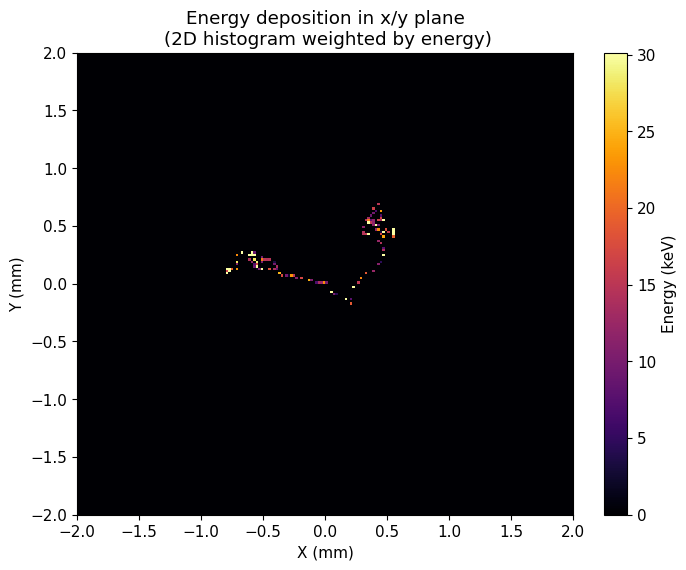

<Figure size 800x600 with 0 Axes>

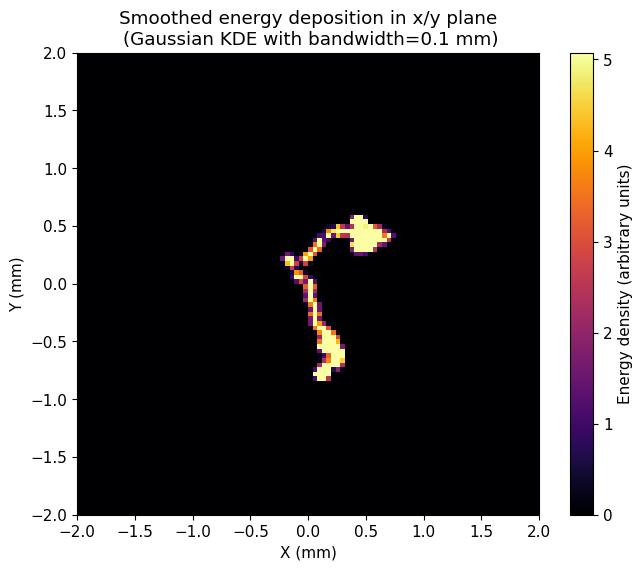

In [38]:
x1 = electrons_data['stepX'][idx]
y1 = electrons_data['stepY'][idx]
z1 = electrons_data['stepZ'][idx]
energy1 = electrons_data['stepEnergy_keV'][idx]
time1 = electrons_data['stepTime_ns'][idx]
srt1 = np.argsort(time1)

# print('Range of event {}: {:4.4}mm'.format(idx, ComputeRange(x[srt],y[srt],z[srt])))

marker_sizes = (energy1 - min(energy1)) / (max(energy1) - min(energy1)) * 100
time_normalized = time1 - min(time1) #(time - min(time)) / (max(time) - min(time)) * 200

# idx = idx+1

x2 = electrons_data['stepX'][idx+1]
y2 = electrons_data['stepY'][idx+1]
z2 = electrons_data['stepZ'][idx+1]
energy2 = electrons_data['stepEnergy_keV'][idx+1]
time2 = electrons_data['stepTime_ns'][idx+1]
srt2 = np.argsort(time2)

marker_sizes = (energy2 - min(energy2)) / (max(energy2) - min(energy2)) * 100
time_normalized = time2 - min(time2) #(time - min(time)) / (max(time) - min(time)) * 200

x = np.concatenate([x1, x2])
y = np.concatenate([y1, y2])
z = np.concatenate([z1, z2])
energy = np.concatenate([energy1, energy2])




# Project that event onto the x/y plane to get a 2D histogram image. Weight each point by its energy deposition to get a sense of the energy density in different regions of the plane.
plt.figure(figsize=(8, 6))
plt.hist2d(x, y, bins=200, range=[[-box_size, box_size], [-box_size, box_size]], weights=energy, cmap='inferno', norm=plt.Normalize(vmin=0, vmax=np.percentile(energy, 99)))
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Energy deposition in x/y plane\n (2D histogram weighted by energy)')
plt.colorbar(label='Energy (keV)')
# Set the colorscale to logarithmic to better see the structure in the energy deposition.
plt.figure(figsize=(8, 6))


# # Now plot it using a smoothed 2D histogram (gaussian kernel density estimation) to get a smoother image of the energy density in the x/y plane. Use a bandwidth of 0.1 mm for the kernel.
from scipy.ndimage import gaussian_filter
# Smooth the histogram above
hist, xedges, yedges = np.histogram2d(x, y, bins=100, range=[[-box_size, box_size], [-box_size, box_size]], weights=energy)
kde_values = gaussian_filter(hist, sigma=0.5) # convert bandwidth from mm to bins

plt.figure(figsize=(8, 6))
plt.imshow(kde_values, extent=(-box_size, box_size, -box_size, box_size), origin='lower', cmap='inferno', norm=plt.Normalize(vmin=0, vmax=np.percentile(kde_values, 99)))
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Smoothed energy deposition in x/y plane\n (Gaussian KDE with bandwidth=0.1 mm)')
plt.colorbar(label='Energy density (arbitrary units)')  



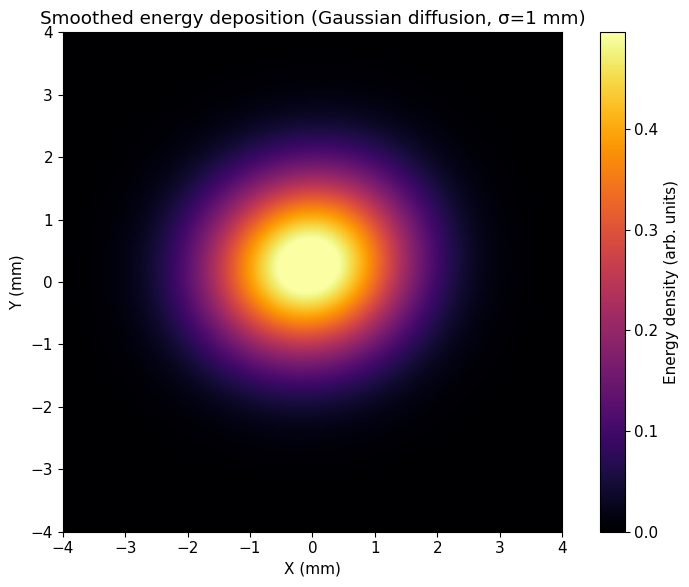

In [54]:

bins = 200
bandwidth_mm = 1  # your desired diffusion length in mm
box_size = 4

# 2D energy histogram
hist, xedges, yedges = np.histogram2d(
    x, y,
    bins=bins,
    range=[[-box_size, box_size], [-box_size, box_size]],
    weights=energy
)

# Convert mm -> bins
dx = (2 * box_size) / bins  # mm/bin (same for x and y with your ranges)
sigma_bins = bandwidth_mm / dx

# Gaussian diffusion (smoothing)
smoothed = gaussian_filter(hist, sigma=sigma_bins, mode="constant")

# Plot
plt.figure(figsize=(8, 6))
plt.imshow(
    smoothed.T,  # transpose so x is horizontal and y is vertical (matches edges)
    extent=(-box_size, box_size, -box_size, box_size),
    origin="lower",
    cmap="inferno",
    vmin=0,
    vmax=np.percentile(smoothed, 99),
    aspect="equal"
)
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.title(f"Smoothed energy deposition (Gaussian diffusion, σ={bandwidth_mm} mm)")
plt.colorbar(label="Energy density (arb. units)")
plt.tight_layout()